In [17]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict

In [18]:
#define state

class  BMIState(TypedDict):
        height: float
        weight: float
        bmi: float
        category: str
        

In [19]:
# BMI Function

def calculate_bmi(state: BMIState) -> BMIState:

    height = state['height']
    weight = state['weight']

    bmi = weight / (height ** 2)

    state['bmi'] = round(bmi, 2)

    return state

In [20]:
def categorize_bmi(state = BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        category = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        category = 'Normal weight'
    elif 25 <= bmi < 29.9:
        category = 'Overweight'
    else:
        category = 'Obesity'

    state['category'] = category

    return state

In [21]:
#define the graph

graph = StateGraph(BMIState)

#add the nodes

graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("Add Label", categorize_bmi)

#add the edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "Add Label")
graph.add_edge("Add Label", END)

#compile the graph
workflow= graph.compile()

In [22]:
#execute the graph

workflow.invoke({

    "height": 1.75,
    "weight": 70
})

{'height': 1.75, 'weight': 70, 'bmi': 22.86, 'category': 'Normal weight'}

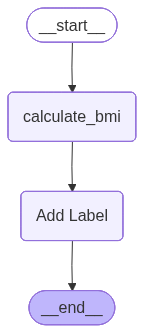

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())